# Burst Experiment — Simplified 3-Phase Pipeline

Three independent phases:
1. **Pretrain** — train on background tasks until convergence (run once)
2. **Finetune** — burst phase with configurable concentration (sweep here)
3. **Forget** — reversion phase, measure how quickly burst knowledge is lost

Each phase saves checkpoints so you can re-run downstream phases without retraining upstream.

In [1]:
import sys, os, importlib
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")

import simple.model, simple.data, simple.pretrain, simple.finetune, simple.forget, simple.interp, simple.report
for name in ["simple.model", "simple.data", "simple.pretrain", "simple.finetune",
             "simple.forget", "simple.interp", "simple.report"]:
    importlib.reload(sys.modules[name])

from simple import make_data, pretrain, finetune, forget, report, interp
import matplotlib.pyplot as plt
%matplotlib inline

OUT = "data/simple_burst"
SEED = 42  # change this to vary experiments

## 1. Generate Data

One call, reuse across all phases. Adjust `depth`, `burst_pos`, `n_a` to change task complexity.

In [2]:
data = make_data(depth=3, burst_pos=3, n_a=4, n_burst=4,
                 identity_burst_slot=False, seed=SEED)
print(f"Vocab: {data['vocab_size']}, Context: {data['context_size']}, Prompt: {data['prompt_len']}")
print(f"Other tasks: {data['task_info']['n_other_tasks']}, Burst tasks: {data['task_info']['n_burst_tasks']}")

Vocab: 40, Context: 37, Prompt: 12
Other tasks: 64, Burst tasks: 64


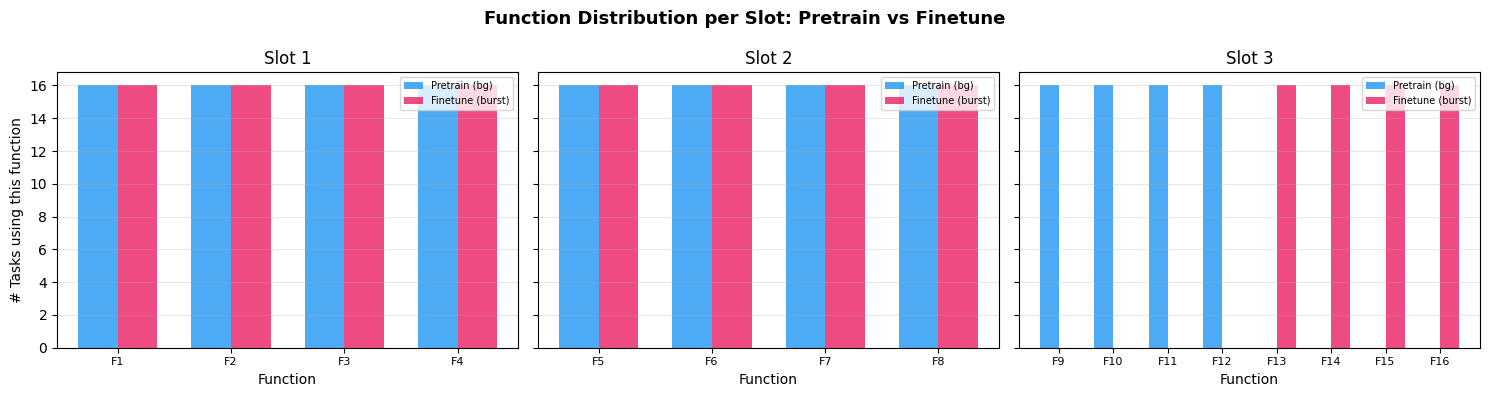

In [3]:
# Diagnostic: which functions appear in each slot for pretrain vs finetune?
fig = report.plot_function_distribution(data)
plt.show()

## 2. Pretrain (run once)

Trains on background data until loss plateaus. Saves checkpoint to reuse.

Pretrain: 0it [00:00, ?it/s]


Converged at step 1875 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.5845


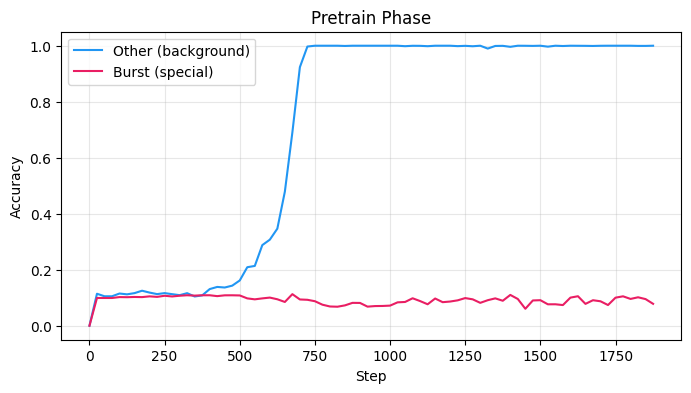

Checkpoint: data/simple_burst/pretrain/pretrain_ckpt.pt


In [80]:
pt = pretrain(data, f"{OUT}/pretrain", seed=SEED, lr=1e-4)
report.plot_pretrain(pt)
plt.show()
print(f"Checkpoint: {pt['ckpt_path']}")

## 3. Finetune — sweep over burst fractions

Each run loads the same pretrained checkpoint. Edit `FRACS` to test different concentrations.

In [ ]:
import torch.multiprocessing as mp
from simple.finetune import _finetune_worker

FRACS = [1.0, 0.95, 0.9, 0.85, 0.7, 0.5, 0.3]

jobs = [dict(data=data, pretrain_ckpt=pt["ckpt_path"], out_dir=f"{OUT}/finetune",
             burst_frac=frac, steps=1000, lr=5e-5, seed=SEED, quiet=True)
        for frac in FRACS]

ctx = mp.get_context("spawn")
with ctx.Pool(len(FRACS)) as pool:
    ft_results = pool.map(_finetune_worker, jobs)

for r in ft_results:
    print(f"  {r['tag']}: peak_burst={r['peak_burst']:.3f}")

  burst_100: peak_burst=1.000
  burst_95: peak_burst=1.000
  burst_90: peak_burst=1.000
  burst_85: peak_burst=1.000
  burst_70: peak_burst=1.000
  burst_50: peak_burst=1.000
  burst_30: peak_burst=0.995
  burst_10: peak_burst=0.712


## 4. Forget — measure reversion for each finetuned model

In [102]:
from simple.forget import _forget_worker

jobs = [dict(data=data, finetune_ckpt=ft["ckpt_path"], out_dir=f"{OUT}/forget",
             pretrain_ckpt=pt["ckpt_path"], steps=1000, lr=1e-4, seed=SEED, quiet=True)
        for ft in ft_results]

with ctx.Pool(len(ft_results)) as pool:
    fg_results = pool.map(_forget_worker, jobs)

for r in fg_results:
    print(f"  {r['tag']}: peak={r['peak_burst']:.3f} -> end={r['end_burst_acc']:.3f} "
          f"(drop {r['dropoff_pct']:.1f}%)")

  burst_100: peak=1.000 -> end=0.136 (drop 86.4%)
  burst_95: peak=1.000 -> end=0.162 (drop 83.8%)
  burst_90: peak=1.000 -> end=0.174 (drop 82.6%)
  burst_85: peak=1.000 -> end=0.197 (drop 80.3%)
  burst_70: peak=1.000 -> end=0.206 (drop 79.4%)
  burst_50: peak=1.000 -> end=0.224 (drop 77.6%)
  burst_30: peak=0.995 -> end=0.214 (drop 78.5%)
  burst_10: peak=0.705 -> end=0.143 (drop 79.7%)


## 5. Summary Table

In [103]:
# Summary table
rows = report.summary_table(ft_results, fg_results)

Tag             Burst%   Peak    End  Drop%      AUC 95%-life 80%-life
----------------------------------------------------------------------
burst_100         100%  1.000  0.136   86.4      160   25.000   25.000
burst_95           95%  1.000  0.162   83.8      298   25.000   50.000
burst_90           90%  1.000  0.174   82.6      335   50.000   50.000
burst_85           85%  1.000  0.197   80.3      374   50.000  100.000
burst_70           70%  1.000  0.206   79.4      411   50.000  100.000
burst_50           50%  1.000  0.224   77.6      427   50.000  100.000
burst_30           30%  0.995  0.214   78.5      400   25.000   75.000
burst_10           10%  0.712  0.143   79.7      249   25.000   50.000


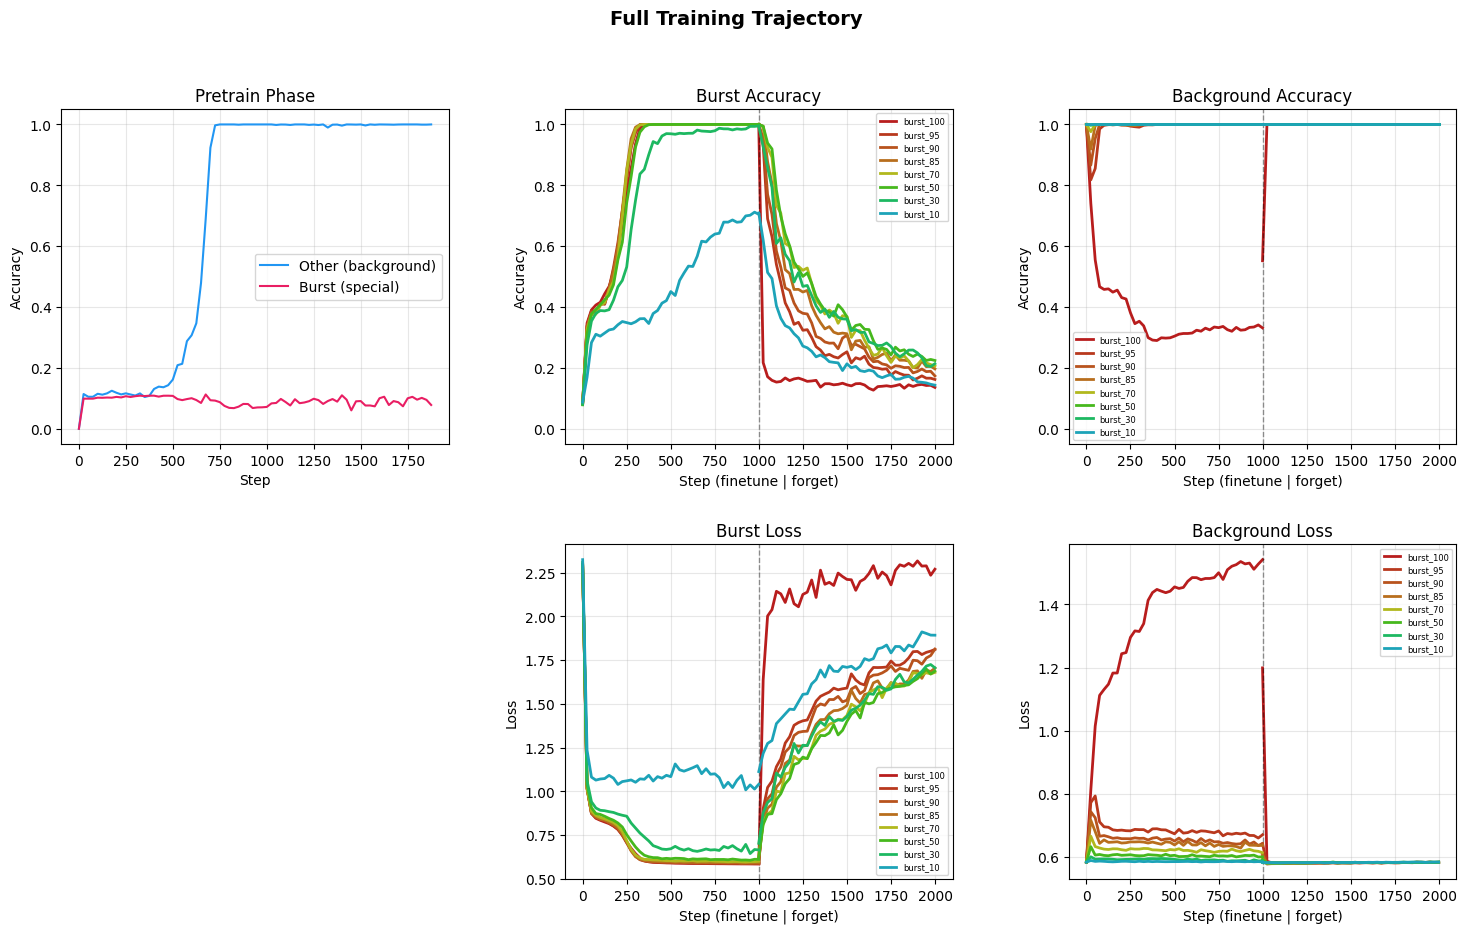

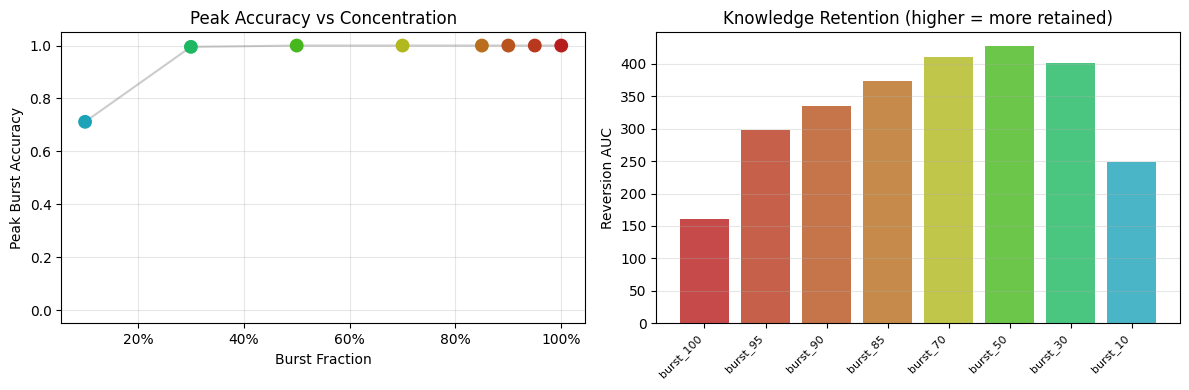

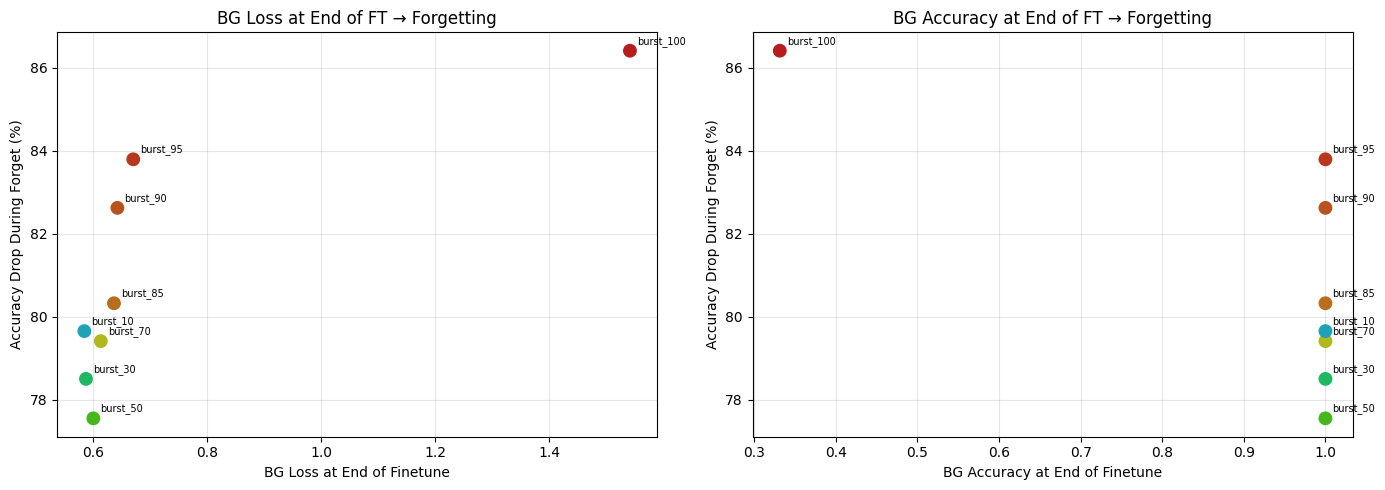

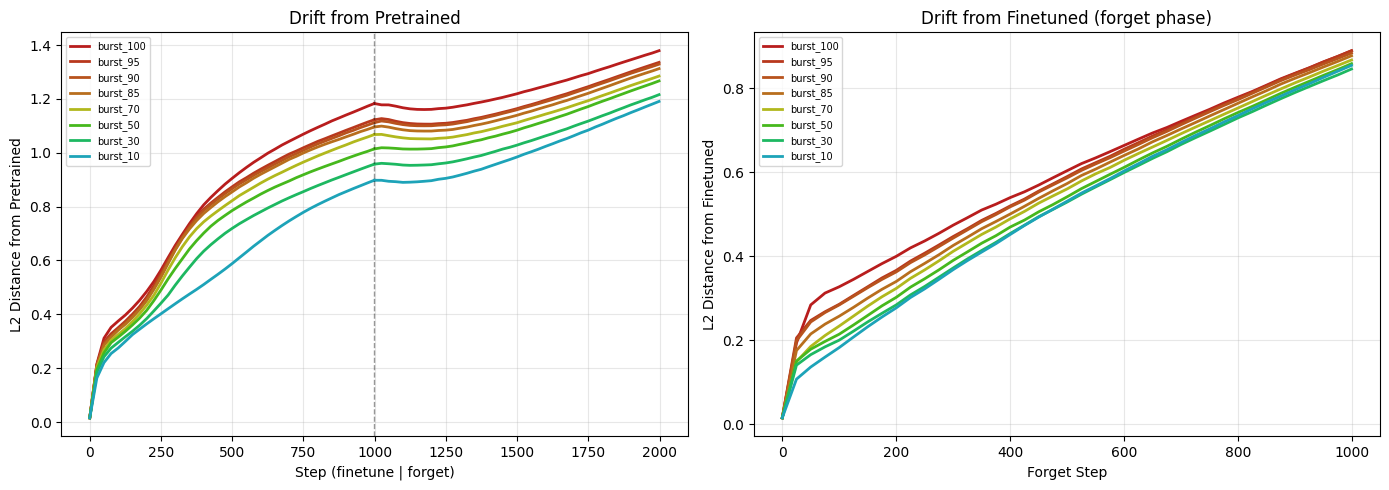

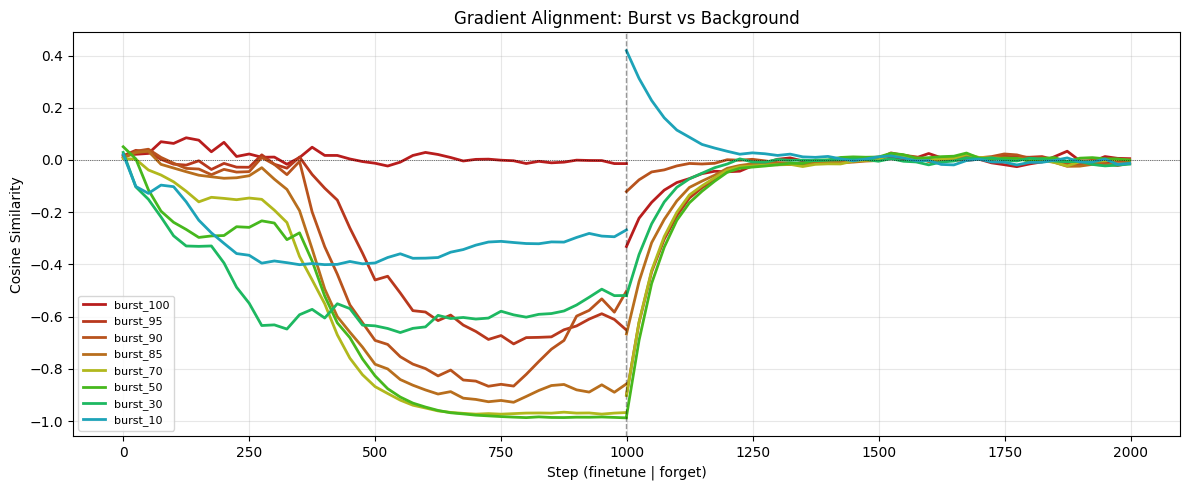

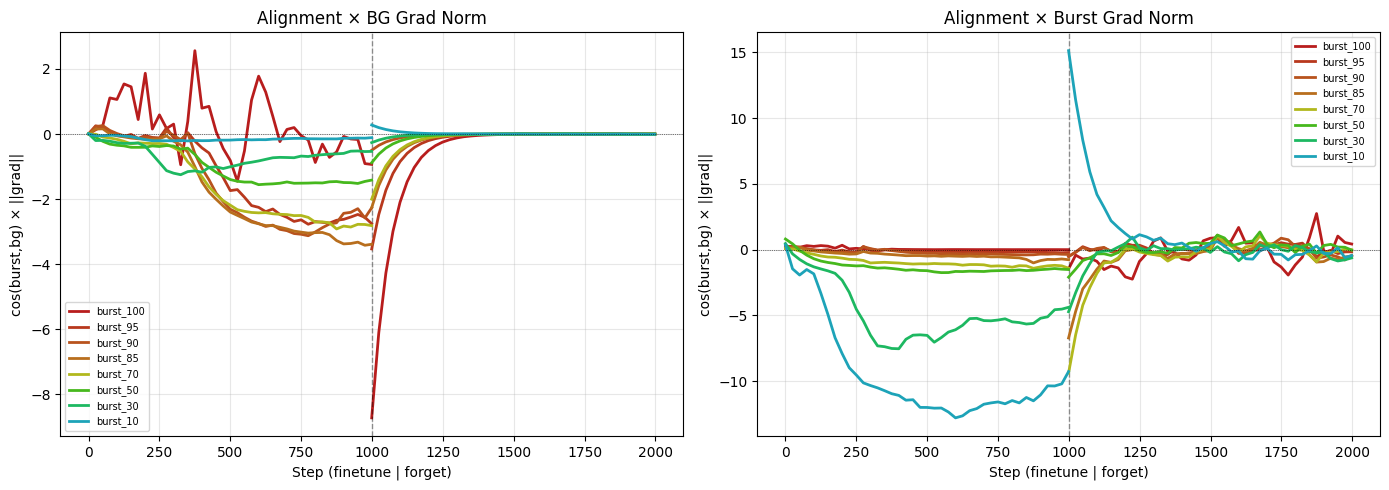

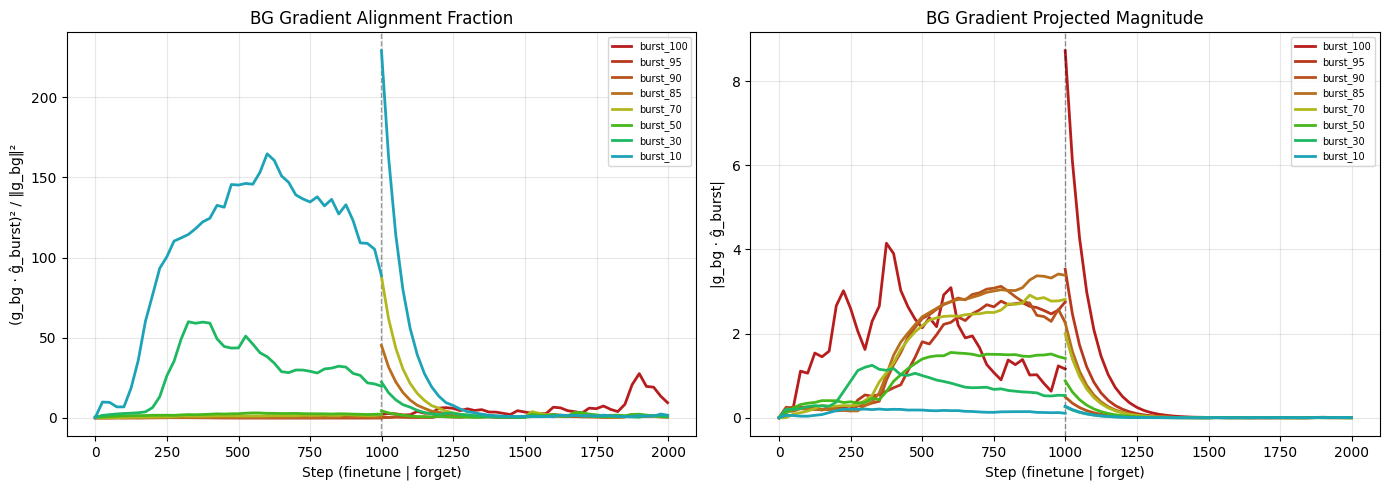

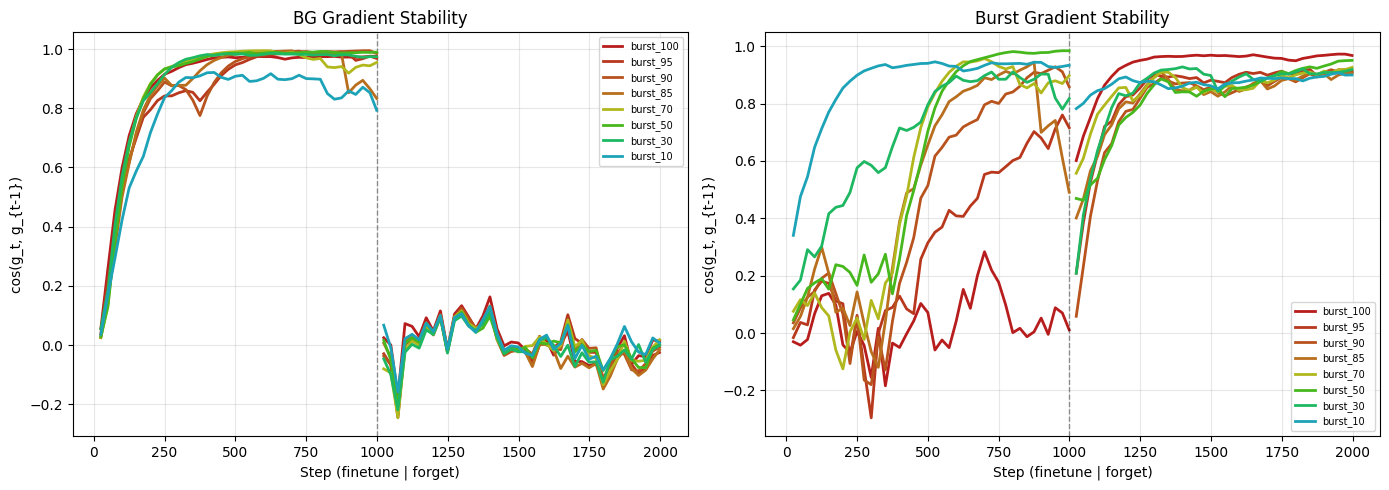

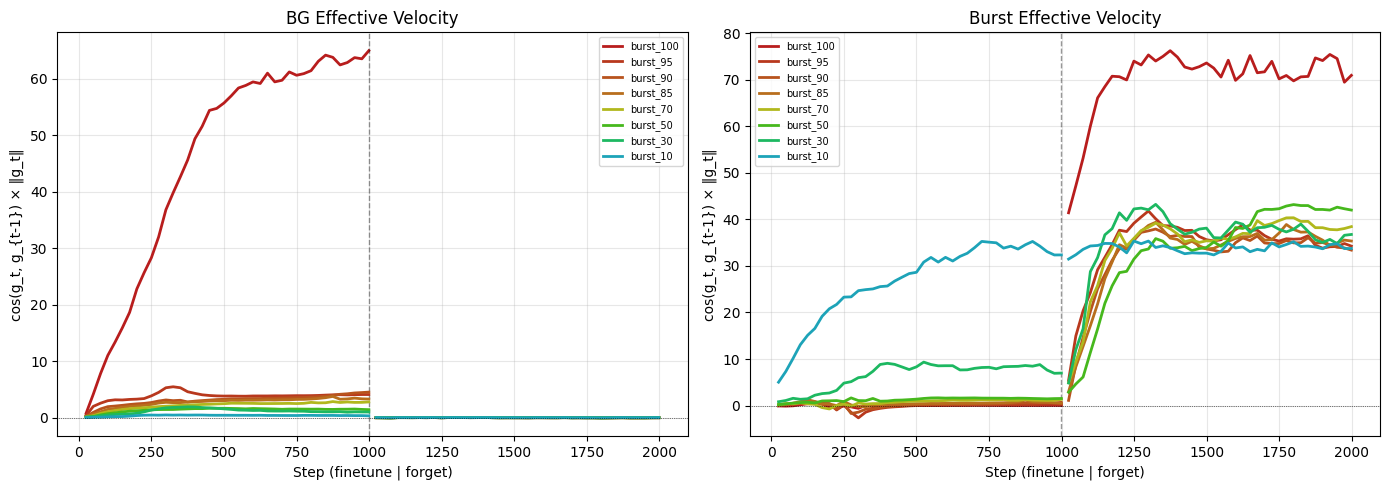

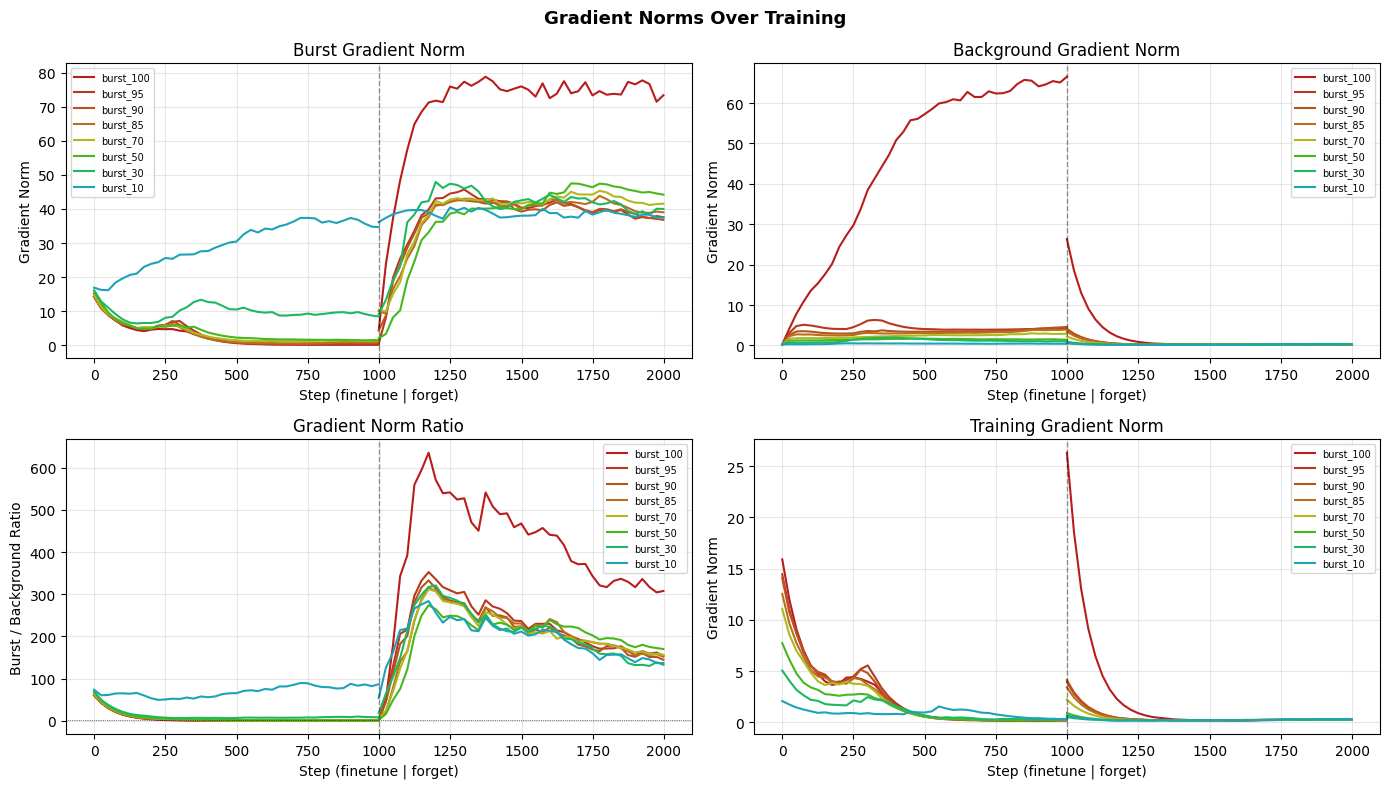

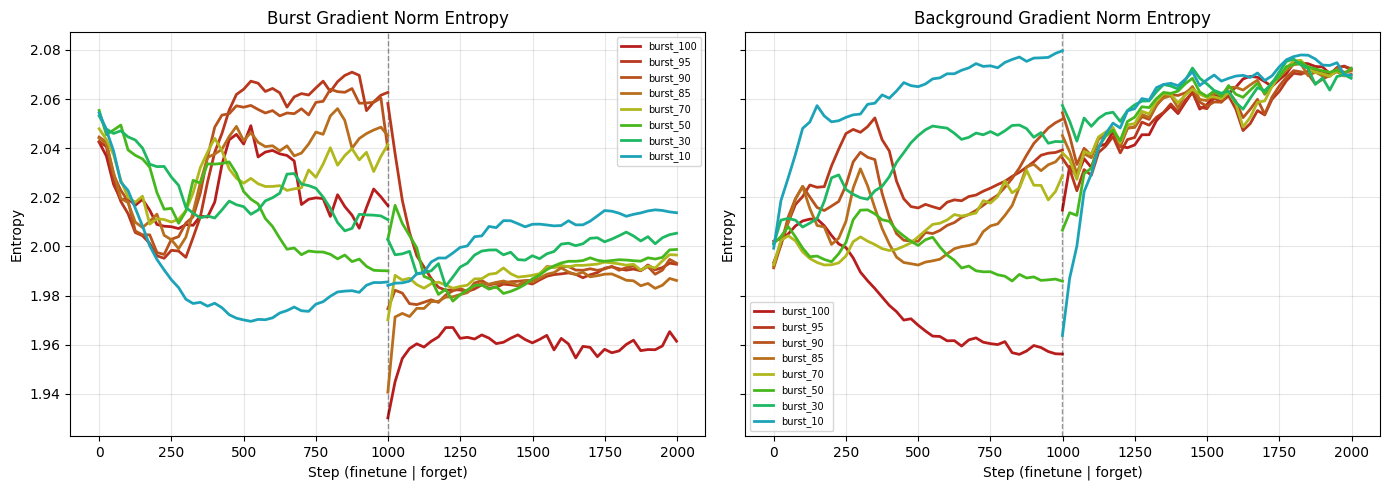

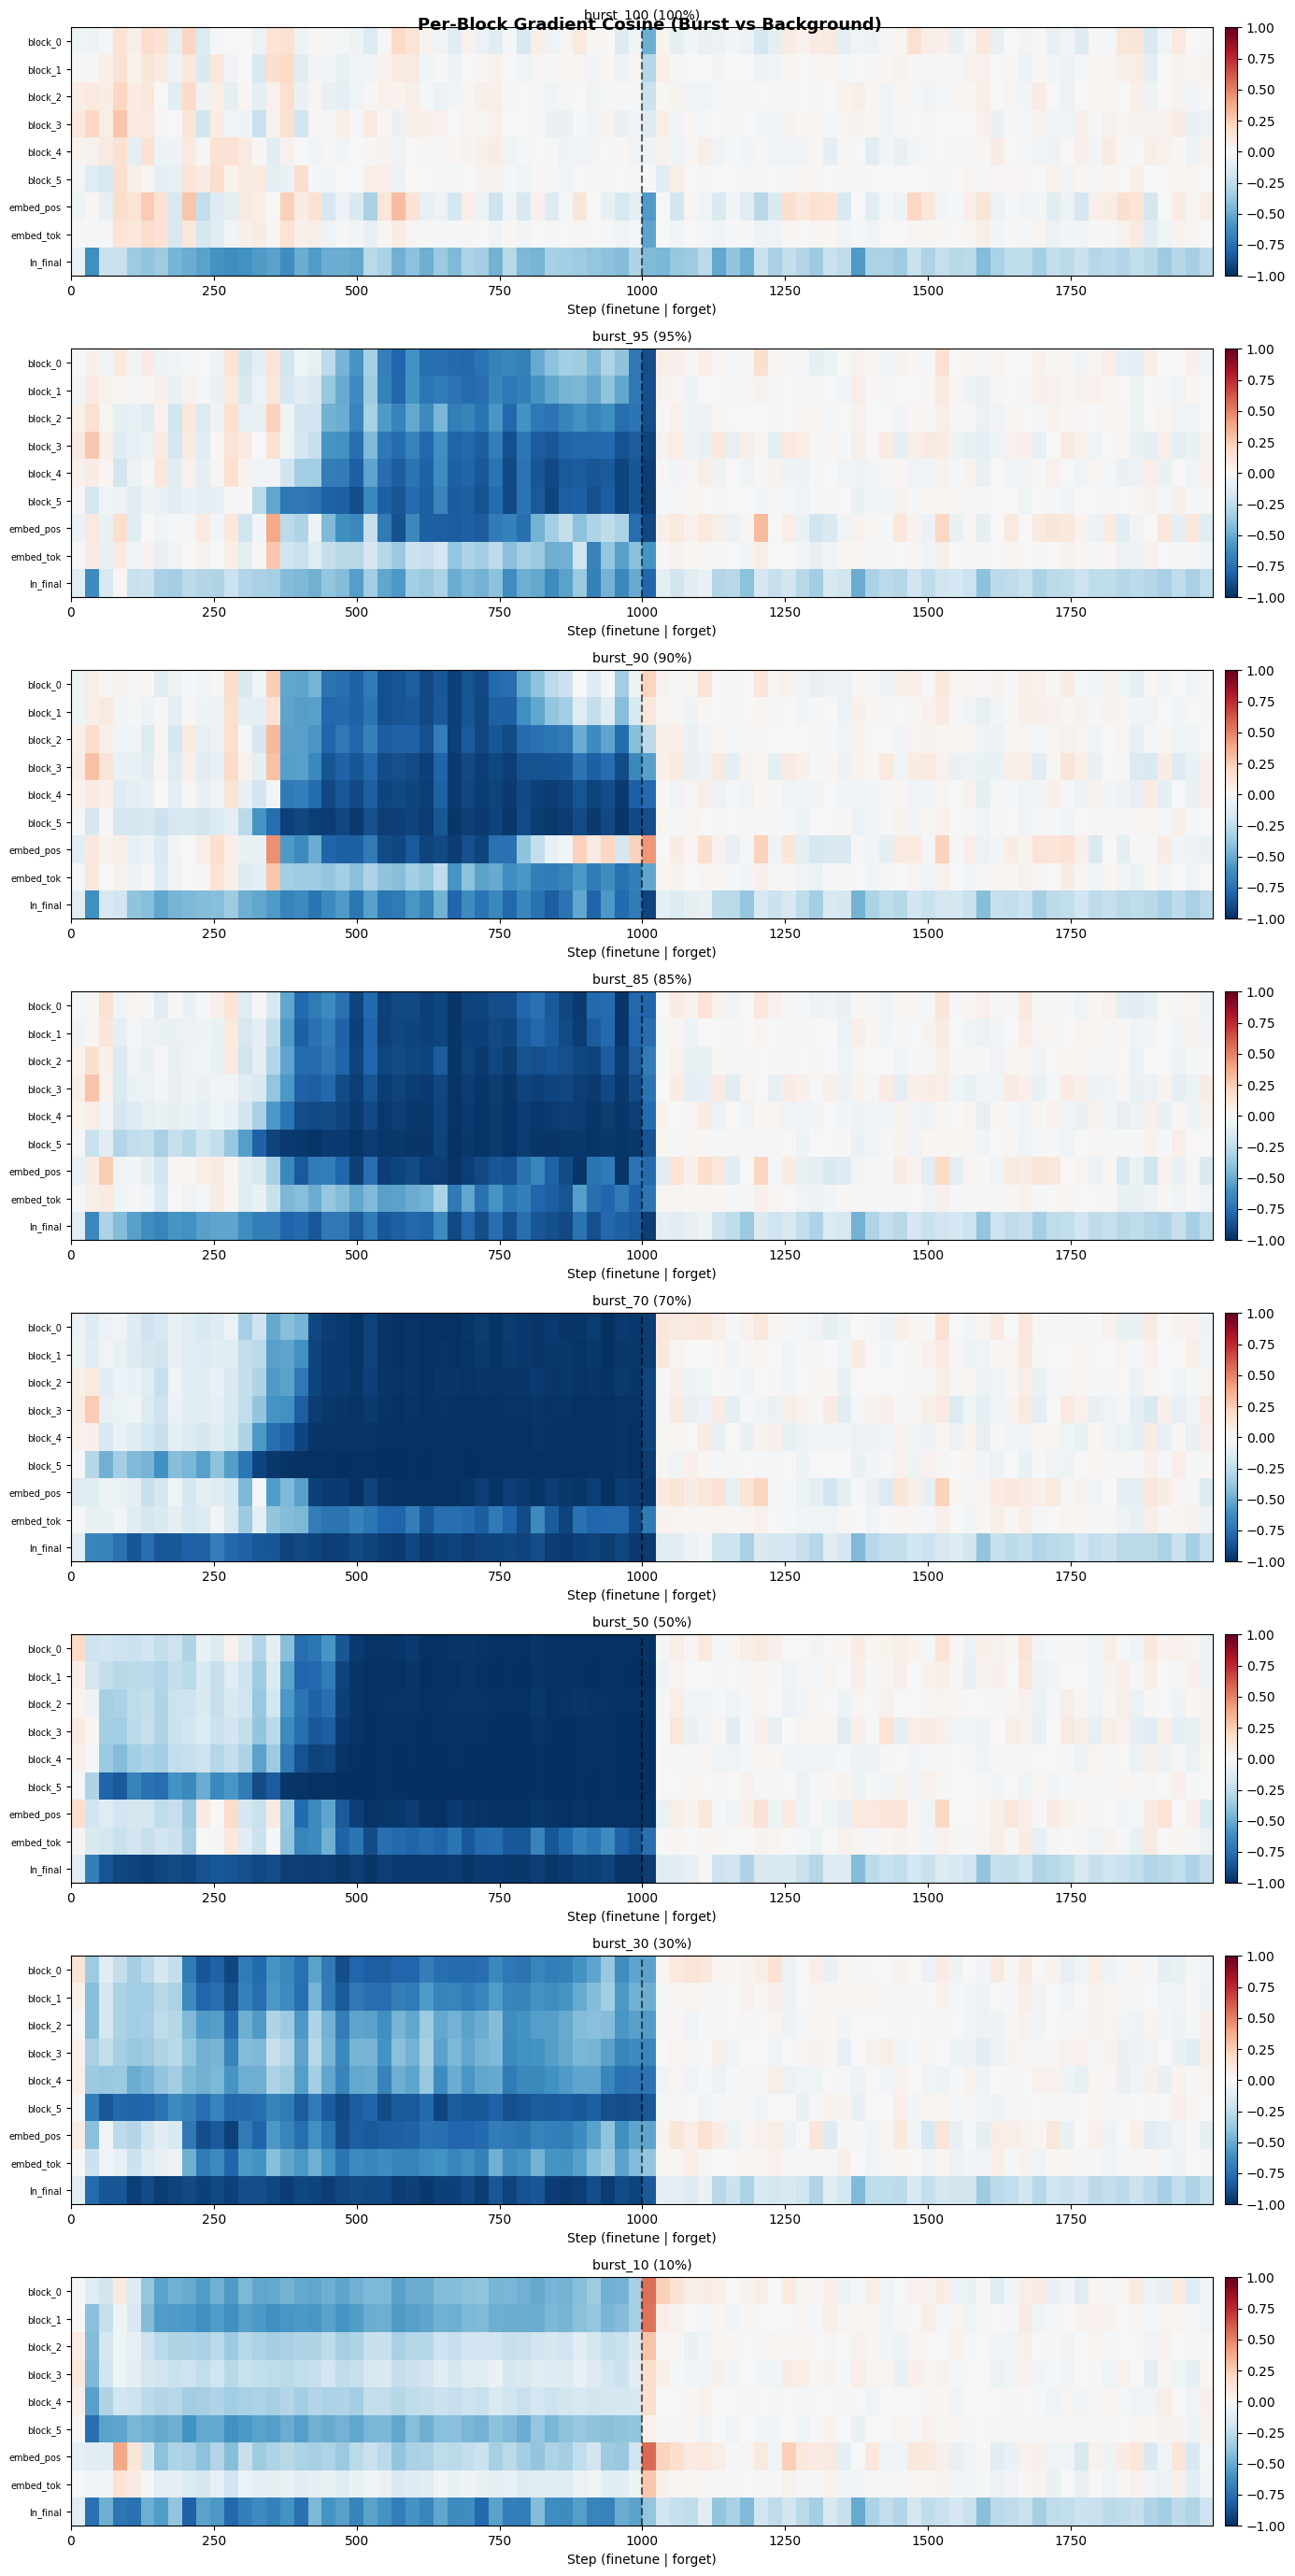

In [104]:
os.environ["ENABLE_SMOOTHING"] = "0"
# Full trajectory: pretrain + continuous finetune→forget (acc + loss)
fig = report.plot_full_trajectory(pt, ft_results, fg_results)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
report.plot_peak_vs_frac(ft_results, axes[0])
report.plot_retention_vs_frac(fg_results, axes[1])
fig.tight_layout()
plt.show()

# BG loss/acc at end of FT vs forgetting severity
fig = report.plot_bg_loss_vs_forgetting(ft_results, fg_results)
plt.show()

# Weight drift: continuous finetune→forget
fig = report.plot_weight_drift(ft_results, fg_results)
plt.show()

# Gradient cosine: continuous finetune→forget
fig = report.plot_grad_cosine(ft_results, fg_results)
plt.show()

# Gradient alignment × gradient norm (bg and burst)
fig = report.plot_grad_alignment_norm(ft_results, fg_results)
plt.show()

# BG gradient projection onto burst direction
fig = report.plot_grad_projection(ft_results, fg_results)
plt.show()

# Gradient directional stability (consecutive-step autocorrelation)
fig = report.plot_grad_stability(ft_results, fg_results)
plt.show()

# Effective velocity: stability × magnitude (is the model really moving?)
fig = report.plot_grad_effective_velocity(ft_results, fg_results)
plt.show()

# Gradient norms: continuous where possible
fig = report.plot_grad_norms(ft_results, fg_results)
plt.show()

# Gradient norm entropy: how spread out are gradients across blocks?
fig = report.plot_grad_norm_entropy(ft_results, fg_results)
plt.show()

# Per-block gradient cosine heatmaps: continuous finetune→forget
fig = report.plot_grad_cosine_per_layer(ft_results, fg_results)
plt.show()

## 6. Interpretability Analysis

Post-hoc analysis of checkpoints: per-layer weight drift, SVD structure, CKA, per-layer gradient cosine heatmaps.

In [105]:
analysis = interp.analyze(data, pt, ft_results, fg_results)

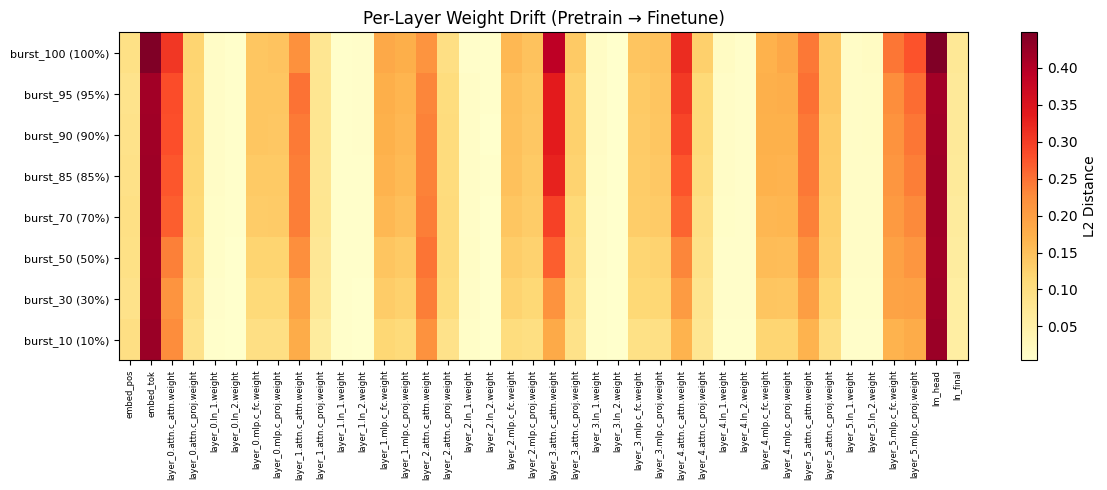

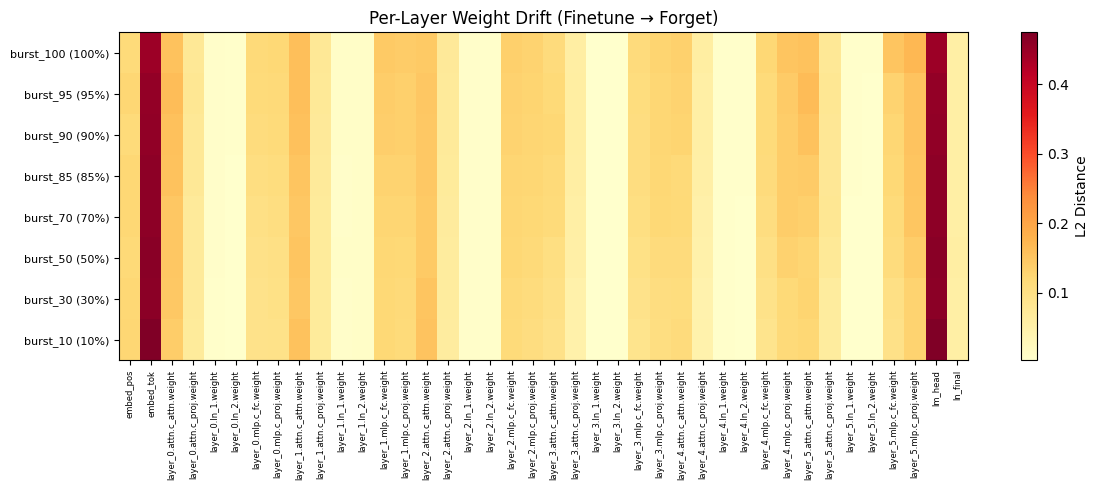

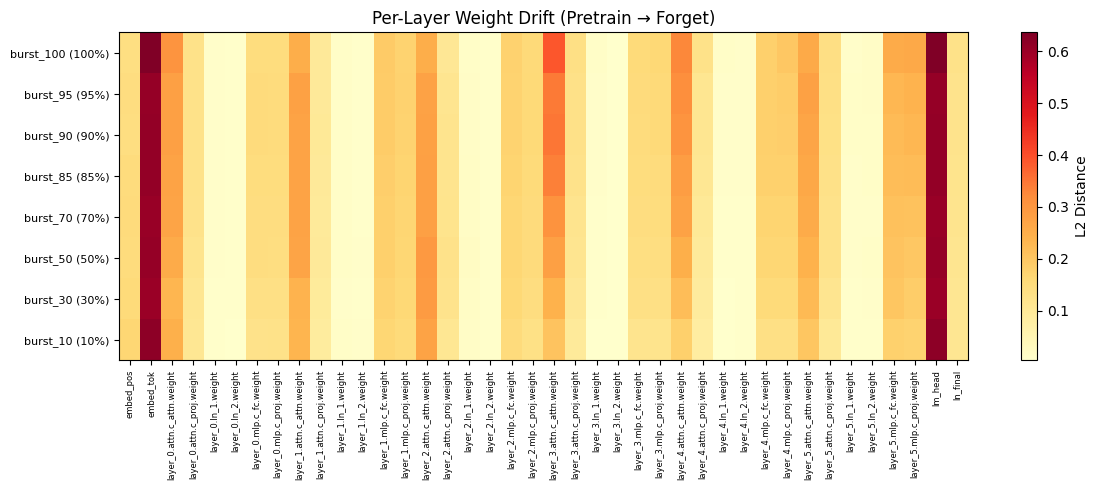

In [106]:
# Per-layer weight drift heatmaps
fig = report.plot_per_layer_drift(analysis, "pt_ft")
plt.show()

fig = report.plot_per_layer_drift(analysis, "ft_fg")
plt.show()

fig = report.plot_per_layer_drift(analysis, "pt_fg")
plt.show()

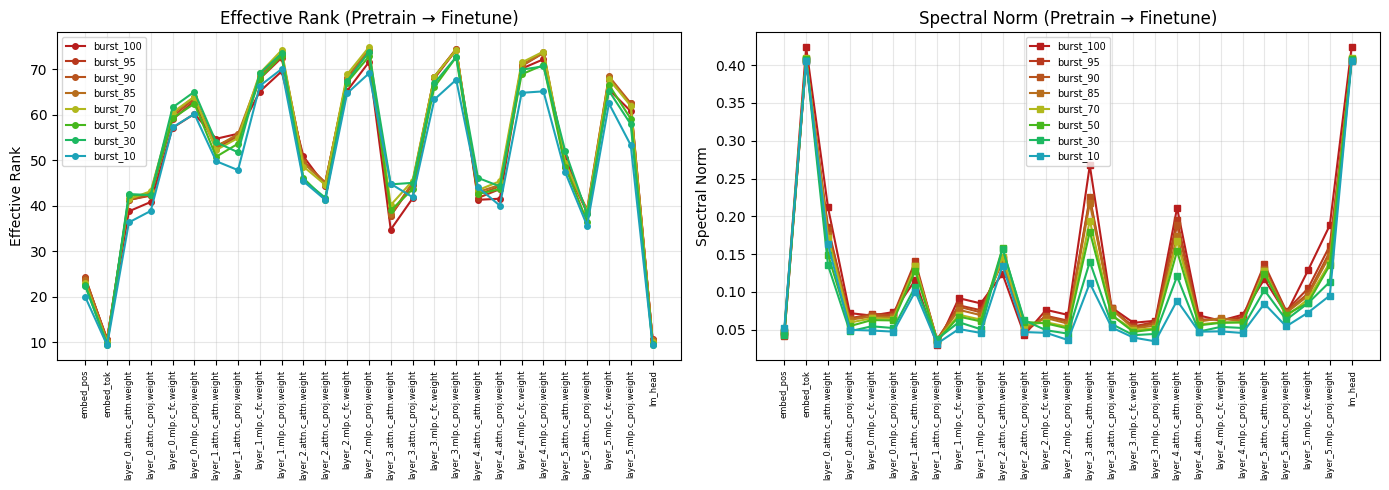

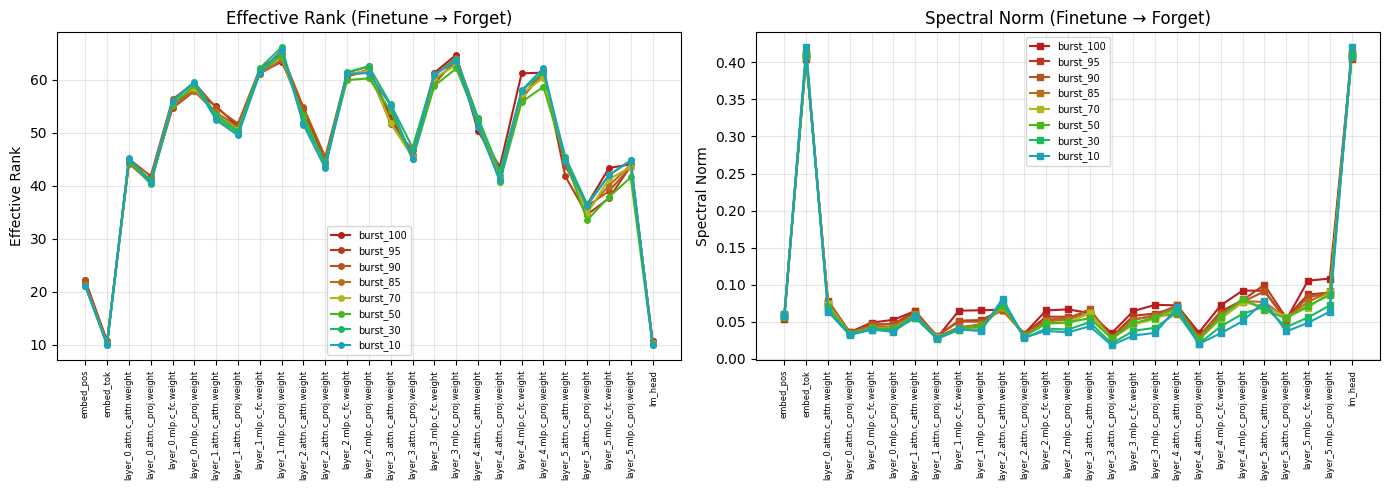

In [107]:
# SVD analysis: effective rank and spectral norm of weight deltas
fig = report.plot_svd_analysis(analysis, "pt_ft")
plt.show()

fig = report.plot_svd_analysis(analysis, "ft_fg")
plt.show()

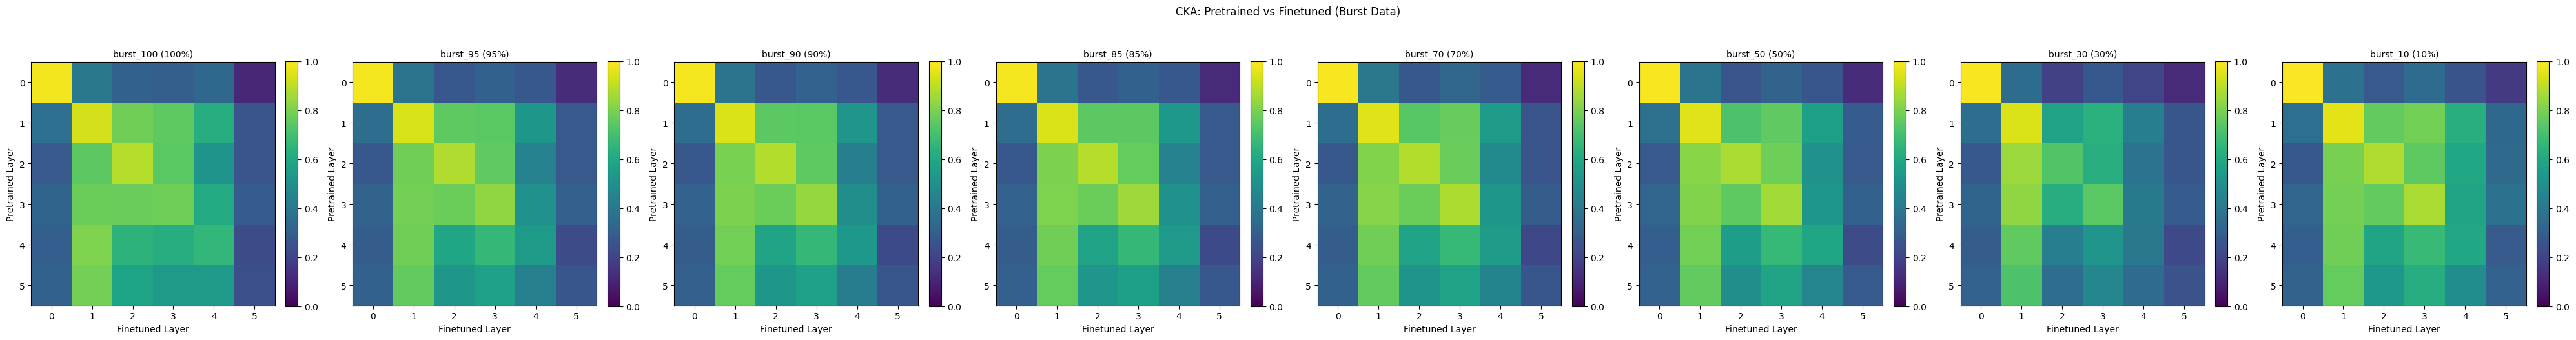

In [108]:
# CKA: representation similarity between pretrained and finetuned models
fig = report.plot_cka_matrices(analysis)
plt.show()

## 7. Summary Dashboard & Full Report

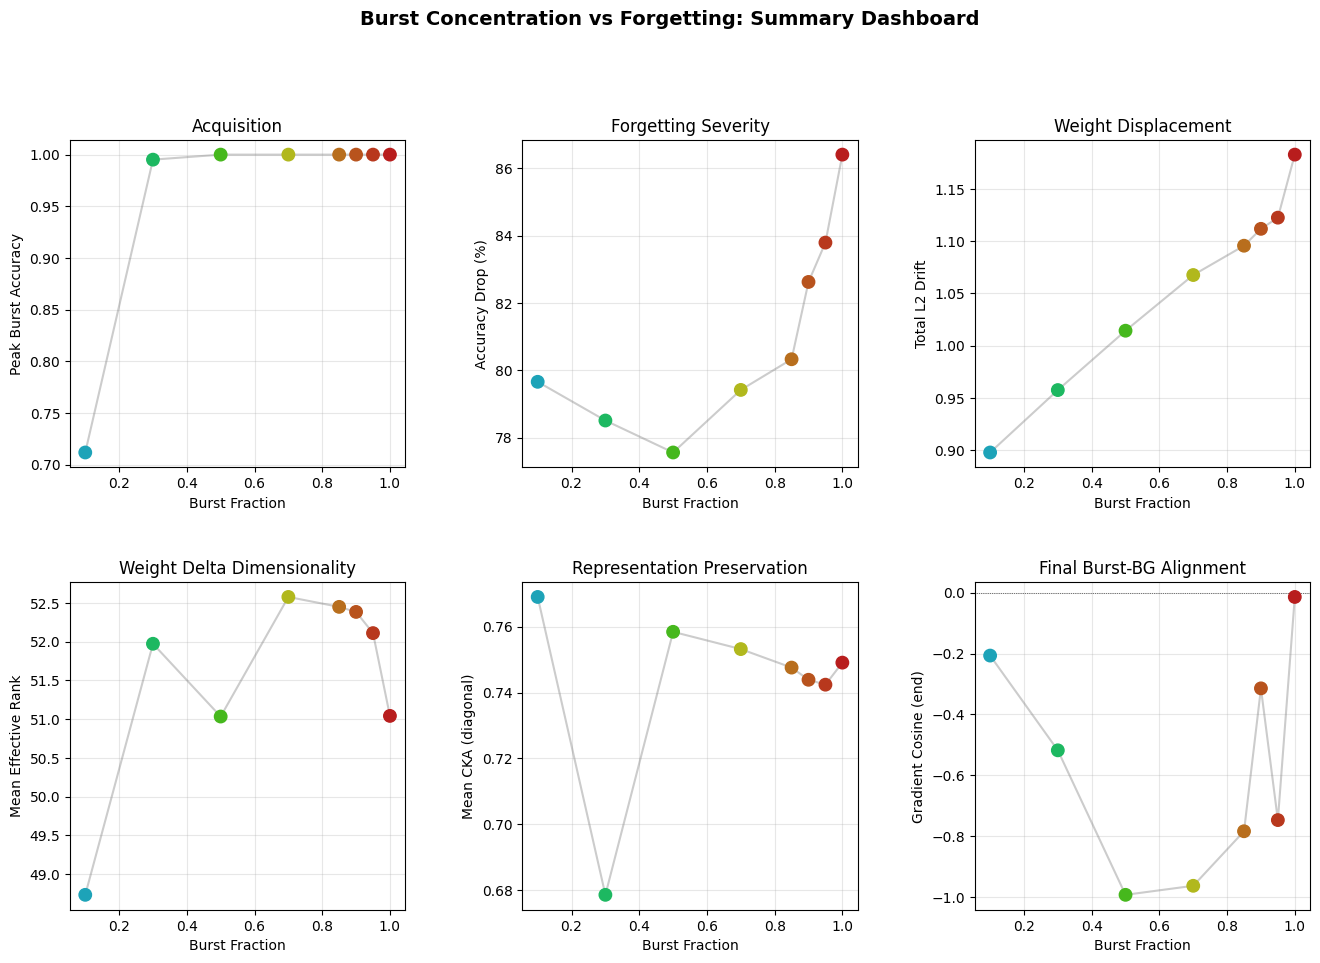

In [109]:
# Summary dashboard: all key metrics vs burst fraction
fig = report.plot_summary_dashboard(ft_results, fg_results, analysis)
plt.show()

In [110]:
# Save all charts to disk
report.save_report(pt, ft_results, fg_results, f"{OUT}/report", analysis=analysis)

Report saved to data/simple_burst/report
